# 01. Marketing Incrementality

Marketing is one of the most common places where causal inference becomes directly tied to money.

A team may ask:

- Did the campaign create revenue that would not have happened otherwise?
- Which channel is actually incremental after accounting for organic demand?
- Should we scale spend, pause spend, or reallocate budget?
- Which customers or markets should receive the next campaign?

Those questions are causal questions. They are not answered by attribution alone. Attribution assigns credit to touchpoints that happened before a conversion. Incrementality asks what would have happened in a credible counterfactual world where the marketing action did not occur.

In this notebook, we will build a practical marketing incrementality workflow using simulations that mirror common industry settings: customer holdouts, geo experiments, matched-market tests, attribution comparisons, power planning, and executive readouts.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain the difference between attribution and incrementality.
- Define marketing estimands such as lift, incremental revenue, incremental ROAS, and contribution profit.
- Analyze a customer-level holdout experiment.
- Diagnose why advertising experiments can be noisy even with many customers.
- Analyze a geo-level incrementality test with difference-in-differences.
- Use a simple synthetic-control-style matched market analysis.
- Translate causal estimates into budget decisions.
- Identify practical threats such as spillovers, budget reallocation, auction interference, seasonality, and weak pre-trends.

## 1. Setup

We will use a consistent visual style and a few helper functions for reporting estimates.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from IPython.display import Markdown, display
from graphviz import Digraph
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
import seaborn as sns
import statsmodels.formula.api as smf


rng = np.random.default_rng(20260429)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 130


def dollars(x, digits=0):
    return f"${x:,.{digits}f}"


def pct(x, digits=1):
    return f"{100 * x:.{digits}f}%"


def ratio(x, digits=2):
    return f"{x:.{digits}f}x"


def styled_money_table(df, money_cols=None, pct_cols=None, ratio_cols=None):
    money_cols = money_cols or []
    pct_cols = pct_cols or []
    ratio_cols = ratio_cols or []

    fmt = {}
    for col in money_cols:
        fmt[col] = lambda v: dollars(v, 0)
    for col in pct_cols:
        fmt[col] = lambda v: pct(v, 2)
    for col in ratio_cols:
        fmt[col] = lambda v: ratio(v, 2)

    return df.style.format(fmt)

## 2. Attribution Is Not Incrementality

A common marketing dashboard reports attributed conversions:

> A customer clicked an ad, then converted. Therefore the ad gets credit.

That can be useful for operations, but it does not answer whether the ad caused the conversion. A high-intent customer may have purchased anyway. A brand-search click may be a navigational shortcut. A coupon affiliate may capture demand created by other channels. A retargeting ad may reach people who were already about to buy.

The incrementality question is:

$$
E[Y(1) - Y(0)]
$$

where:

- $Y(1)$ is the outcome if the unit receives the marketing action.
- $Y(0)$ is the outcome if the unit does not receive the marketing action.

For revenue, a useful campaign-level estimand is:

$$
\text{Incremental Revenue} = N_{\text{treated}}\left(E[Y \mid W=1] - E[Y \mid W=0]\right)
$$

When spend matters, teams often report incremental return on ad spend:

$$
\text{iROAS} = \frac{\text{Incremental Revenue}}{\text{Marketing Spend}}
$$

For decision-making, iROAS is still not enough. If revenue has gross margin $m$, the contribution profit from the campaign is:

$$
\text{Contribution Profit} = m \cdot \text{Incremental Revenue} - \text{Marketing Spend}
$$

This distinction is why marketing incrementality is a causal inference problem, not just a tracking problem.

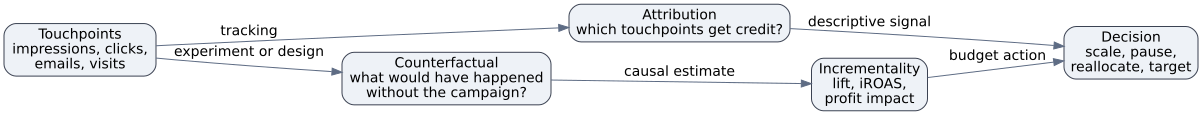

In [2]:
dot = Digraph("marketing_incrementality_stack", format="svg")
dot.attr(rankdir="LR", bgcolor="transparent")
dot.attr("node", shape="box", style="rounded,filled", color="#3B4252", fillcolor="#EEF2F7", fontname="DejaVu Sans")
dot.attr("edge", color="#5E6C84", fontname="DejaVu Sans")

dot.node("touch", "Touchpoints\nimpressions, clicks,\nemails, visits")
dot.node("attr", "Attribution\nwhich touchpoints get credit?")
dot.node("counter", "Counterfactual\nwhat would have happened\nwithout the campaign?")
dot.node("lift", "Incrementality\nlift, iROAS,\nprofit impact")
dot.node("decision", "Decision\nscale, pause,\nreallocate, target")

dot.edge("touch", "attr", label="tracking")
dot.edge("touch", "counter", label="experiment or design")
dot.edge("attr", "decision", label="descriptive signal")
dot.edge("counter", "lift", label="causal estimate")
dot.edge("lift", "decision", label="budget action")

dot

Marketing papers and industry tutorials often emphasize randomized incrementality tests because they directly compare treated customers with a control or holdout group. Berman and Feit (2019) describe advertising experiments as lift or holdout experiments that compare customers randomly assigned to receive a marketing communication with customers assigned not to receive it. The same paper also notes an important practical challenge: sales lift can be imprecisely estimated, especially when purchases are rare and control groups are small.

The implication for industry work is simple: an incrementality program is partly statistical design and partly operating discipline. You need tracking, randomization or a credible quasi-experiment, sufficient sample size, and a decision rule before looking at results.

## 3. A Marketing Measurement Map

Different marketing questions need different designs. The table below is a practical starting point.

In [3]:
measurement_map = pd.DataFrame(
    [
        {
            "business question": "Did this email, push, or CRM journey create value?",
            "common design": "Customer-level randomized holdout",
            "unit": "customer",
            "best when": "The platform can withhold treatment for a random subset.",
            "main risk": "Small holdouts create noisy lift estimates.",
        },
        {
            "business question": "Did paid media create total demand?",
            "common design": "Geo incrementality test",
            "unit": "market or region",
            "best when": "User-level holdout is unavailable or spillovers are likely.",
            "main risk": "Few geos, seasonality, and nonparallel pre-trends.",
        },
        {
            "business question": "Did a national campaign work without a randomized test?",
            "common design": "Synthetic control or matched markets",
            "unit": "market over time",
            "best when": "One or a few treated markets have long pre-period histories.",
            "main risk": "No donor combination reproduces the treated market.",
        },
        {
            "business question": "Which customers should receive treatment?",
            "common design": "Uplift or CATE modeling after randomized exposure",
            "unit": "customer",
            "best when": "There is an experiment with rich pre-treatment covariates.",
            "main risk": "Model finds outcome risk rather than treatment responsiveness.",
        },
        {
            "business question": "How should spend be reallocated across channels?",
            "common design": "Portfolio of experiments plus MMM or causal time series",
            "unit": "channel-market-time",
            "best when": "Multiple channels interact and budgets move over time.",
            "main risk": "Attribution and budget rules create feedback loops.",
        },
    ]
)

display(measurement_map)

,business question,common design,unit,best when,main risk
0,"Did this email, push, or CRM journey create va...",Customer-level randomized holdout,customer,The platform can withhold treatment for a rand...,Small holdouts create noisy lift estimates.
1,Did paid media create total demand?,Geo incrementality test,market or region,User-level holdout is unavailable or spillover...,"Few geos, seasonality, and nonparallel pre-tre..."
2,Did a national campaign work without a randomi...,Synthetic control or matched markets,market over time,One or a few treated markets have long pre-per...,No donor combination reproduces the treated ma...
3,Which customers should receive treatment?,Uplift or CATE modeling after randomized exposure,customer,There is an experiment with rich pre-treatment...,Model finds outcome risk rather than treatment...
4,How should spend be reallocated across channels?,Portfolio of experiments plus MMM or causal ti...,channel-market-time,Multiple channels interact and budgets move ov...,Attribution and budget rules create feedback l...


## 4. Customer-Level Holdout Experiment

Start with the cleanest design: randomize eligible customers into treatment and holdout.

Example:

- Eligible audience: customers who visited a product page but did not purchase.
- Treatment: retargeting ad or email coupon.
- Control: no campaign contact during the measurement window.
- Outcome: revenue during the next 14 days.
- Estimand: average incremental revenue per treated customer.

The key property is random assignment:

$$
W_i \perp (Y_i(1),Y_i(0))
$$

If assignment is truly random, the difference in average outcomes estimates the causal lift:

$$
\hat{\tau} = \bar{Y}_{W=1} - \bar{Y}_{W=0}
$$

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def simulate_customer_holdout(n=60_000, treatment_share=0.90, seed=11):
    local_rng = np.random.default_rng(seed)

    prior_sessions = local_rng.poisson(3, n)
    prior_orders = local_rng.poisson(0.35, n)
    cart_value = local_rng.lognormal(mean=3.7, sigma=0.45, size=n)
    deal_sensitivity = local_rng.beta(2.2, 3.0, n)
    loyalty = local_rng.beta(2.5, 2.0, n)
    ad_fatigue = local_rng.gamma(shape=1.4, scale=0.7, size=n)

    baseline_score = (
        -4.25
        + 0.28 * prior_sessions
        + 0.55 * prior_orders
        + 0.95 * loyalty
        + 0.012 * cart_value
        - 0.30 * ad_fatigue
    )
    p0 = sigmoid(baseline_score)

    incremental_prob = (
        0.004
        + 0.022 * deal_sensitivity
        + 0.006 * (prior_sessions >= 2)
        - 0.011 * loyalty
        - 0.003 * np.minimum(ad_fatigue, 3)
    )
    incremental_prob = np.clip(incremental_prob, -0.004, 0.055)
    p1 = np.clip(p0 + incremental_prob, 0.001, 0.80)

    # Shared uniform random numbers create coherent potential outcomes.
    purchase_draw = local_rng.uniform(size=n)
    order_noise = local_rng.lognormal(mean=0.0, sigma=0.30, size=n)
    potential_revenue_0 = (purchase_draw < p0) * cart_value * order_noise
    potential_revenue_1 = (purchase_draw < p1) * cart_value * order_noise

    treatment = local_rng.binomial(1, treatment_share, n)
    observed_revenue = np.where(treatment == 1, potential_revenue_1, potential_revenue_0)
    spend = treatment * (0.18 + 0.04 * np.minimum(prior_sessions, 8))
    attributed_revenue = np.where((treatment == 1) & (observed_revenue > 0), observed_revenue, 0.0)

    df = pd.DataFrame(
        {
            "customer_id": np.arange(n),
            "sent_campaign": treatment,
            "prior_sessions": prior_sessions,
            "prior_orders": prior_orders,
            "cart_value": cart_value,
            "deal_sensitivity": deal_sensitivity,
            "loyalty": loyalty,
            "ad_fatigue": ad_fatigue,
            "revenue": observed_revenue,
            "spend": spend,
            "attributed_revenue": attributed_revenue,
            "potential_revenue_0": potential_revenue_0,
            "potential_revenue_1": potential_revenue_1,
            "true_customer_effect": potential_revenue_1 - potential_revenue_0,
        }
    )
    return df


customers = simulate_customer_holdout()

display(customers.head())
print(f"Rows: {len(customers):,}")
print(f"Treatment share: {customers['sent_campaign'].mean():.1%}")
print(f"True average incremental revenue per eligible customer: {dollars(customers['true_customer_effect'].mean(), 3)}")

,customer_id,sent_campaign,prior_sessions,prior_orders,cart_value,deal_sensitivity,loyalty,ad_fatigue,revenue,spend,attributed_revenue,potential_revenue_0,potential_revenue_1,true_customer_effect
0,0,1,2,0,79.286588,0.053902,0.734263,1.171436,0.0000,0.26,0.0000,0.0000,0.0000,0.0
1,1,1,0,1,28.701745,0.329945,0.244801,0.809134,0.0000,0.18,0.0000,0.0000,0.0000,0.0
2,2,1,2,0,36.514027,0.625819,0.654021,0.422371,0.0000,0.26,0.0000,0.0000,0.0000,0.0
3,3,1,3,0,93.532341,0.422867,0.571410,0.508400,107.9998,0.30,107.9998,107.9998,107.9998,0.0
4,4,1,3,0,25.046993,0.201260,0.311922,0.140162,0.0000,0.30,0.0000,0.0000,0.0000,0.0


Rows: 60,000
Treatment share: 90.1%
True average incremental revenue per eligible customer: $0.428


This simulated data has the properties that make marketing experiments interesting:

- Most customers purchase nothing in the measurement window.
- Baseline conversion probability differs across customers.
- The campaign effect is heterogeneous.
- Some loyal customers would have purchased anyway.
- Spend is observed only for treated customers.
- Attributed revenue is not the same as incremental revenue.

Because we simulated the data, we can see the true potential outcomes. In a real project, those columns do not exist. They are included here only as a teaching device.

In [5]:
holdout_summary = (
    customers.assign(group=np.where(customers["sent_campaign"] == 1, "Sent campaign", "Holdout"))
    .groupby("group")
    .agg(
        customers=("customer_id", "size"),
        conversion_rate=("revenue", lambda x: (x > 0).mean()),
        revenue_per_customer=("revenue", "mean"),
        total_revenue=("revenue", "sum"),
        total_spend=("spend", "sum"),
        attributed_revenue=("attributed_revenue", "sum"),
    )
    .reset_index()
)

display(
    styled_money_table(
        holdout_summary,
        money_cols=["revenue_per_customer", "total_revenue", "total_spend", "attributed_revenue"],
        pct_cols=["conversion_rate"],
    )
)

,group,customers,conversion_rate,revenue_per_customer,total_revenue,total_spend,attributed_revenue
0,Holdout,5945,9.64%,$5,"$30,547",$0,$0
1,Sent campaign,54055,10.56%,$6,"$298,953","$16,215","$298,953"


The descriptive table already shows why attribution can mislead.

Every treated customer who purchases after exposure creates attributed revenue, but many of those customers would have purchased even without exposure. The holdout group is what lets us estimate the counterfactual purchase rate and revenue.

In [6]:
def estimate_randomized_lift(df, treatment_col, outcome_col, cost_col=None, attributed_col=None):
    treated = df[treatment_col].eq(1)
    y_t = df.loc[treated, outcome_col]
    y_c = df.loc[~treated, outcome_col]

    diff = y_t.mean() - y_c.mean()
    se = np.sqrt(y_t.var(ddof=1) / len(y_t) + y_c.var(ddof=1) / len(y_c))
    ci_low = diff - 1.96 * se
    ci_high = diff + 1.96 * se

    out = {
        "treated_n": int(treated.sum()),
        "control_n": int((~treated).sum()),
        "treated_mean": y_t.mean(),
        "control_mean": y_c.mean(),
        "lift_per_treated_unit": diff,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "incremental_revenue": diff * treated.sum(),
    }

    if cost_col is not None:
        spend = df.loc[treated, cost_col].sum()
        out["spend"] = spend
        out["iROAS"] = out["incremental_revenue"] / spend

    if attributed_col is not None and cost_col is not None:
        attributed = df.loc[treated, attributed_col].sum()
        out["attributed_revenue"] = attributed
        out["attributed_ROAS"] = attributed / out["spend"]

    return pd.Series(out)


holdout_est = estimate_randomized_lift(
    customers,
    treatment_col="sent_campaign",
    outcome_col="revenue",
    cost_col="spend",
    attributed_col="attributed_revenue",
)

true_incremental_treated = customers.loc[customers["sent_campaign"].eq(1), "true_customer_effect"].sum()
holdout_est["true_incremental_revenue"] = true_incremental_treated
holdout_est["true_iROAS"] = true_incremental_treated / holdout_est["spend"]

holdout_readout = pd.DataFrame(
    {
        "metric": [
            "Revenue per treated customer",
            "Revenue per holdout customer",
            "Estimated lift per treated customer",
            "95% CI lower",
            "95% CI upper",
            "Estimated incremental revenue",
            "True incremental revenue",
            "Spend",
            "Attributed revenue",
            "Attributed ROAS",
            "Incremental ROAS",
            "True iROAS",
        ],
        "value": [
            holdout_est["treated_mean"],
            holdout_est["control_mean"],
            holdout_est["lift_per_treated_unit"],
            holdout_est["ci_low"],
            holdout_est["ci_high"],
            holdout_est["incremental_revenue"],
            holdout_est["true_incremental_revenue"],
            holdout_est["spend"],
            holdout_est["attributed_revenue"],
            holdout_est["attributed_ROAS"],
            holdout_est["iROAS"],
            holdout_est["true_iROAS"],
        ],
    }
)

display(holdout_readout)

,metric,value
0,Revenue per treated customer,5.530538
1,Revenue per holdout customer,5.138271
2,Estimated lift per treated customer,0.392267
3,95% CI lower,-0.109891
4,95% CI upper,0.894425
5,Estimated incremental revenue,21203.970763
6,True incremental revenue,22844.628646
7,Spend,16214.940000
8,Attributed revenue,298953.213564
9,Attributed ROAS,18.436899


The important line is not attributed revenue. It is the estimated lift relative to the holdout.

If the estimated iROAS is below the attributed ROAS, that is normal. Attribution is counting revenue among exposed customers. Incrementality is estimating revenue caused by exposure.

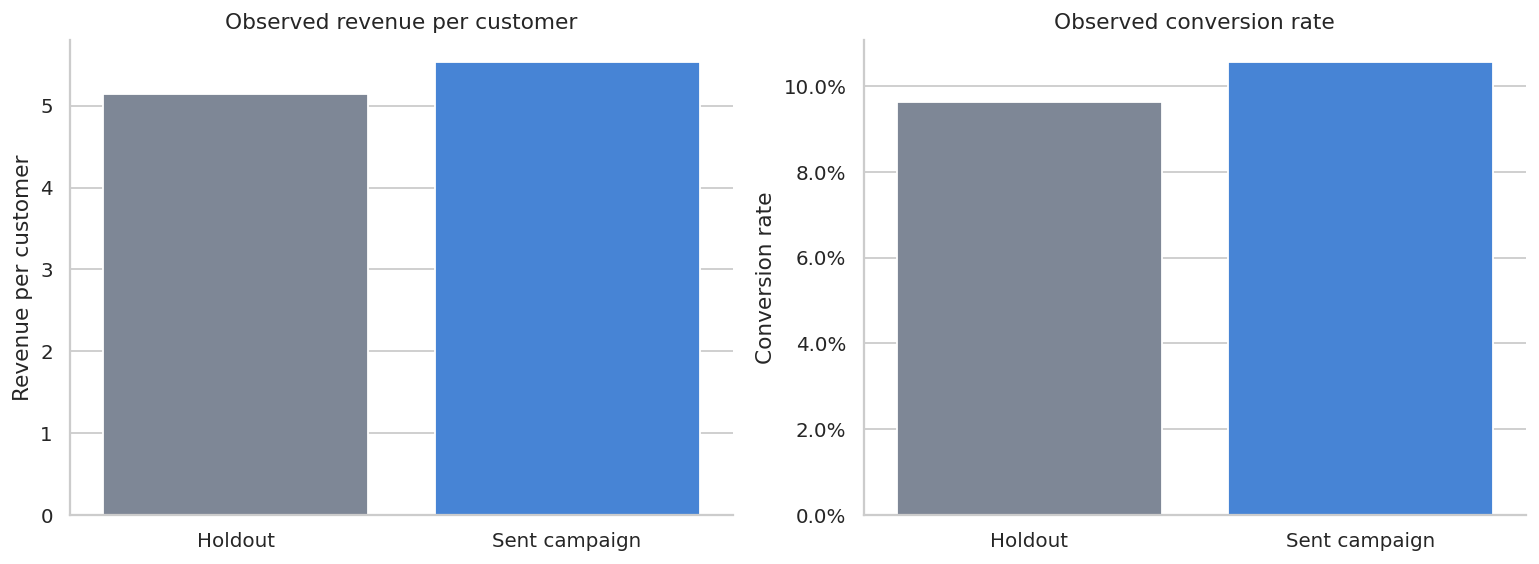

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_df = customers.assign(
    group=np.where(customers["sent_campaign"].eq(1), "Sent campaign", "Holdout"),
    purchased=customers["revenue"].gt(0),
)

mean_df = (
    plot_df.groupby("group")
    .agg(revenue_per_customer=("revenue", "mean"), conversion_rate=("purchased", "mean"))
    .reindex(["Holdout", "Sent campaign"])
    .reset_index()
)

sns.barplot(data=mean_df, x="group", y="revenue_per_customer", ax=axes[0], palette=["#7A869A", "#2F80ED"])
axes[0].set_title("Observed revenue per customer")
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue per customer")

purchase_rates = mean_df.copy()
sns.barplot(data=purchase_rates, x="group", y="conversion_rate", ax=axes[1], palette=["#7A869A", "#2F80ED"])
axes[1].set_title("Observed conversion rate")
axes[1].set_xlabel("")
axes[1].set_ylabel("Conversion rate")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.1f}%")

plt.tight_layout()
plt.show()

### Why Large Marketing Experiments Can Still Be Noisy

Advertising and CRM experiments often have rare outcomes. When most customers have zero revenue, the variance of revenue is large relative to the average lift.

Berman and Feit (2019) discuss this practical issue in advertising experiments: sales lift estimates can be highly imprecise even with large experiments, and marketers often prefer small holdouts such as 5-10% because withholding ads has an opportunity cost.

The next simulation keeps the same customer population but changes the control share. This shows the tradeoff between opportunity cost and statistical precision.

In [8]:
def rerandomization_precision(base_df, control_shares, reps=180, seed=99):
    local_rng = np.random.default_rng(seed)
    y0 = base_df["potential_revenue_0"].to_numpy()
    y1 = base_df["potential_revenue_1"].to_numpy()
    n = len(base_df)
    rows = []

    for control_share in control_shares:
        treatment_share = 1 - control_share
        for rep in range(reps):
            w = local_rng.binomial(1, treatment_share, n)
            observed = np.where(w == 1, y1, y0)
            treated = observed[w == 1]
            control = observed[w == 0]
            diff = treated.mean() - control.mean()
            se = np.sqrt(treated.var(ddof=1) / len(treated) + control.var(ddof=1) / len(control))
            rows.append(
                {
                    "control_share": control_share,
                    "estimate": diff,
                    "ci_width": 2 * 1.96 * se,
                    "control_n": int((w == 0).sum()),
                    "treated_n": int((w == 1).sum()),
                }
            )
    return pd.DataFrame(rows)


precision = rerandomization_precision(customers, control_shares=[0.05, 0.10, 0.20, 0.35, 0.50])

precision_summary = (
    precision.groupby("control_share")
    .agg(
        avg_control_n=("control_n", "mean"),
        estimate_sd=("estimate", "std"),
        median_ci_width=("ci_width", "median"),
        p05=("estimate", lambda x: np.quantile(x, 0.05)),
        p95=("estimate", lambda x: np.quantile(x, 0.95)),
    )
    .reset_index()
)

display(precision_summary)

,control_share,avg_control_n,estimate_sd,median_ci_width,p05,p95
0,0.05,3000.261111,0.317300,1.351238,-0.116946,0.919977
1,0.10,6004.072222,0.283131,0.982845,-0.073902,0.885381
2,0.20,11999.938889,0.183021,0.742297,0.108267,0.678831
3,0.35,21008.466667,0.168346,0.624684,0.164087,0.719893
4,0.50,30006.633333,0.146200,0.599213,0.181827,0.684989


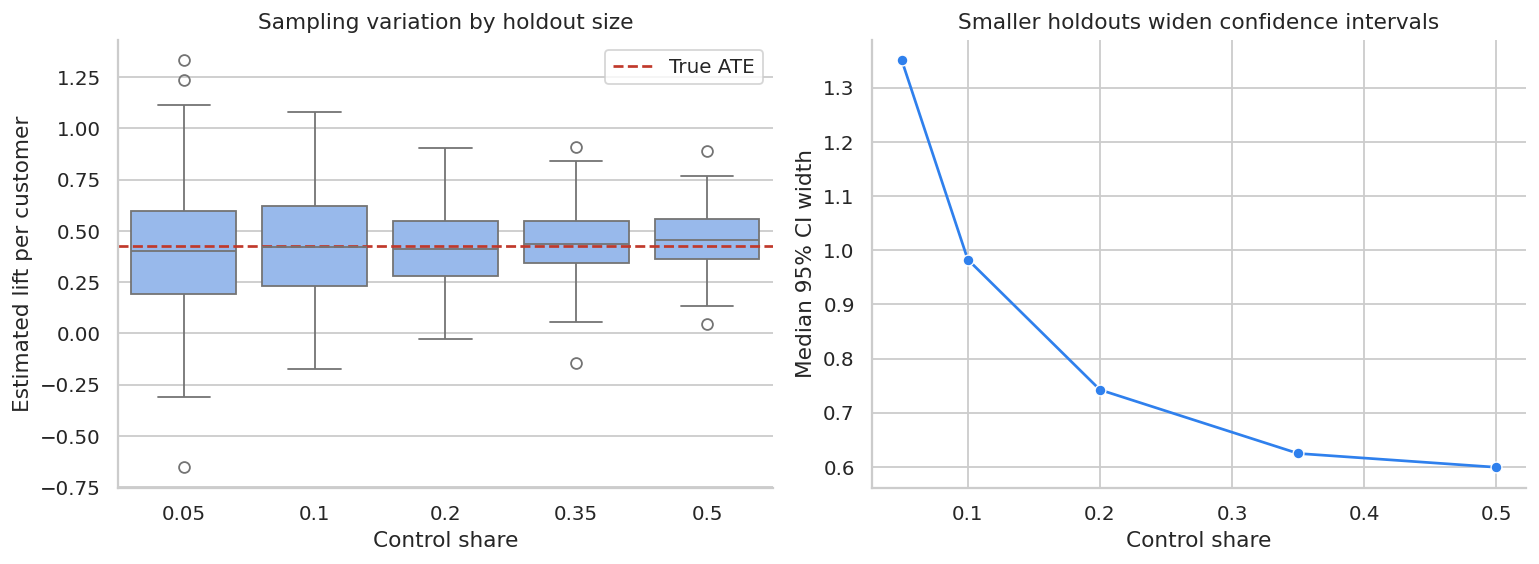

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(
    data=precision,
    x="control_share",
    y="estimate",
    ax=axes[0],
    color="#8AB6F9",
)
axes[0].axhline(customers["true_customer_effect"].mean(), color="#C0392B", linestyle="--", label="True ATE")
axes[0].set_title("Sampling variation by holdout size")
axes[0].set_xlabel("Control share")
axes[0].set_ylabel("Estimated lift per customer")
axes[0].legend()

sns.lineplot(
    data=precision_summary,
    x="control_share",
    y="median_ci_width",
    marker="o",
    ax=axes[1],
    color="#2F80ED",
)
axes[1].set_title("Smaller holdouts widen confidence intervals")
axes[1].set_xlabel("Control share")
axes[1].set_ylabel("Median 95% CI width")

plt.tight_layout()
plt.show()

The lesson is not that every experiment needs a 50% holdout. The lesson is that the holdout size should be justified by the business decision.

If the campaign is expensive and uncertain, a larger holdout may be worth the opportunity cost. If the campaign is low-risk and the goal is ongoing monitoring, a smaller persistent holdout may be enough.

## 5. Geo Incrementality Experiment

Customer-level randomization is often impossible for paid media:

- Ad platforms may not allow clean user-level holdouts.
- Ads can spill over across people in the same household or market.
- Auction dynamics can shift spend from one user to another.
- Offline sales may only be measured at regional granularity.

In those settings, marketers often randomize markets or geographies. The unit becomes a geo-week rather than a customer.

The estimand is usually an average treatment effect on treated geo-weeks:

$$
\tau_{\text{geo}} = E[Y_{gt}(1) - Y_{gt}(0) \mid g \in \text{treated}, t \geq T_0]
$$

A common model is a two-way fixed effects difference-in-differences specification:

$$
Y_{gt} = \alpha_g + \lambda_t + \tau \cdot \text{Treated}_g \times \text{Post}_t + \varepsilon_{gt}
$$

Here $\alpha_g$ controls for stable geo differences and $\lambda_t$ controls for shocks common to all geos in a week.

In [10]:
def simulate_geo_campaign(n_geos=48, n_weeks=34, launch_week=22, seed=202):
    local_rng = np.random.default_rng(seed)
    geos = [f"Geo_{i:02d}" for i in range(n_geos)]
    regions = local_rng.choice(["North", "South", "West", "Central"], size=n_geos)
    geo_size = local_rng.lognormal(mean=10.6, sigma=0.28, size=n_geos)
    online_share = local_rng.beta(3.5, 2.2, size=n_geos)
    trend = local_rng.normal(0.004, 0.004, size=n_geos)

    # Balanced-ish assignment: sort by size and alternate treated/control.
    order = np.argsort(geo_size)
    treated = np.zeros(n_geos, dtype=int)
    treated[order[::2]] = 1
    local_rng.shuffle(treated)

    rows = []
    for i, geo in enumerate(geos):
        geo_base = geo_size[i]
        for week in range(n_weeks):
            post = int(week >= launch_week)
            seasonal = 0.055 * np.sin(2 * np.pi * week / 13) + 0.025 * np.cos(2 * np.pi * week / 6)
            macro = 1 + 0.012 * week
            noise = local_rng.normal(0, geo_base * 0.035)
            baseline = geo_base * (1 + seasonal) * macro * (1 + trend[i] * week) + noise

            ramp = min(max((week - launch_week + 1) / 4, 0), 1)
            true_effect = treated[i] * post * ramp * geo_base * (0.042 + 0.030 * online_share[i])
            spend = treated[i] * post * geo_base * (0.012 + 0.006 * online_share[i]) * local_rng.uniform(0.86, 1.14)
            revenue = baseline + true_effect

            # Last-click style attributed revenue overstates causality for high-intent geos.
            attributed_revenue = treated[i] * post * spend * local_rng.normal(5.6 + 2.2 * online_share[i], 0.45)

            rows.append(
                {
                    "geo": geo,
                    "region": regions[i],
                    "week": week,
                    "post": post,
                    "treated_geo": treated[i],
                    "online_share": online_share[i],
                    "geo_size": geo_size[i],
                    "revenue": revenue,
                    "spend": spend,
                    "attributed_revenue": max(attributed_revenue, 0),
                    "true_effect": true_effect,
                }
            )

    return pd.DataFrame(rows)


geo = simulate_geo_campaign()
geo["treated_post"] = geo["treated_geo"] * geo["post"]

display(geo.head())
print(f"Geo-weeks: {len(geo):,}")
print(f"Geos: {geo['geo'].nunique()}")
print(f"Treated geos: {geo.groupby('geo')['treated_geo'].first().sum()}")
print(f"Launch week: {geo.loc[geo['post'].eq(1), 'week'].min()}")

,geo,region,week,post,treated_geo,online_share,geo_size,revenue,spend,attributed_revenue,true_effect,treated_post
0,Geo_00,North,0,0,1,0.706817,35165.03214,36789.947524,0.0,0.0,0.0,0
1,Geo_00,North,1,0,1,0.706817,35165.03214,38848.359610,0.0,0.0,0.0,0
2,Geo_00,North,2,0,1,0.706817,35165.03214,38624.249025,0.0,0.0,0.0,0
3,Geo_00,North,3,0,1,0.706817,35165.03214,39248.592362,0.0,0.0,0.0,0
4,Geo_00,North,4,0,1,0.706817,35165.03214,37493.107889,0.0,0.0,0.0,0


Geo-weeks: 1,632
Geos: 48
Treated geos: 24
Launch week: 22


Before estimating the treatment effect, we should check whether treated and control markets look comparable before launch.

In [11]:
pre_geo = (
    geo.query("post == 0")
    .groupby(["geo", "treated_geo"])
    .agg(
        pre_revenue=("revenue", "mean"),
        pre_revenue_trend=("revenue", lambda x: np.polyfit(np.arange(len(x)), x, 1)[0]),
        online_share=("online_share", "first"),
        geo_size=("geo_size", "first"),
    )
    .reset_index()
)

balance = (
    pre_geo.groupby("treated_geo")
    .agg(
        geos=("geo", "size"),
        avg_pre_revenue=("pre_revenue", "mean"),
        avg_pre_trend=("pre_revenue_trend", "mean"),
        avg_online_share=("online_share", "mean"),
        avg_geo_size=("geo_size", "mean"),
    )
    .rename(index={0: "Control geos", 1: "Treated geos"})
    .reset_index(names="group")
)

display(
    styled_money_table(
        balance,
        money_cols=["avg_pre_revenue", "avg_pre_trend", "avg_geo_size"],
        pct_cols=["avg_online_share"],
    )
)

,group,geos,avg_pre_revenue,avg_pre_trend,avg_online_share,avg_geo_size
0,Control geos,24,"$49,043",$560,60.79%,"$42,414"
1,Treated geos,24,"$48,202",$677,56.70%,"$40,463"


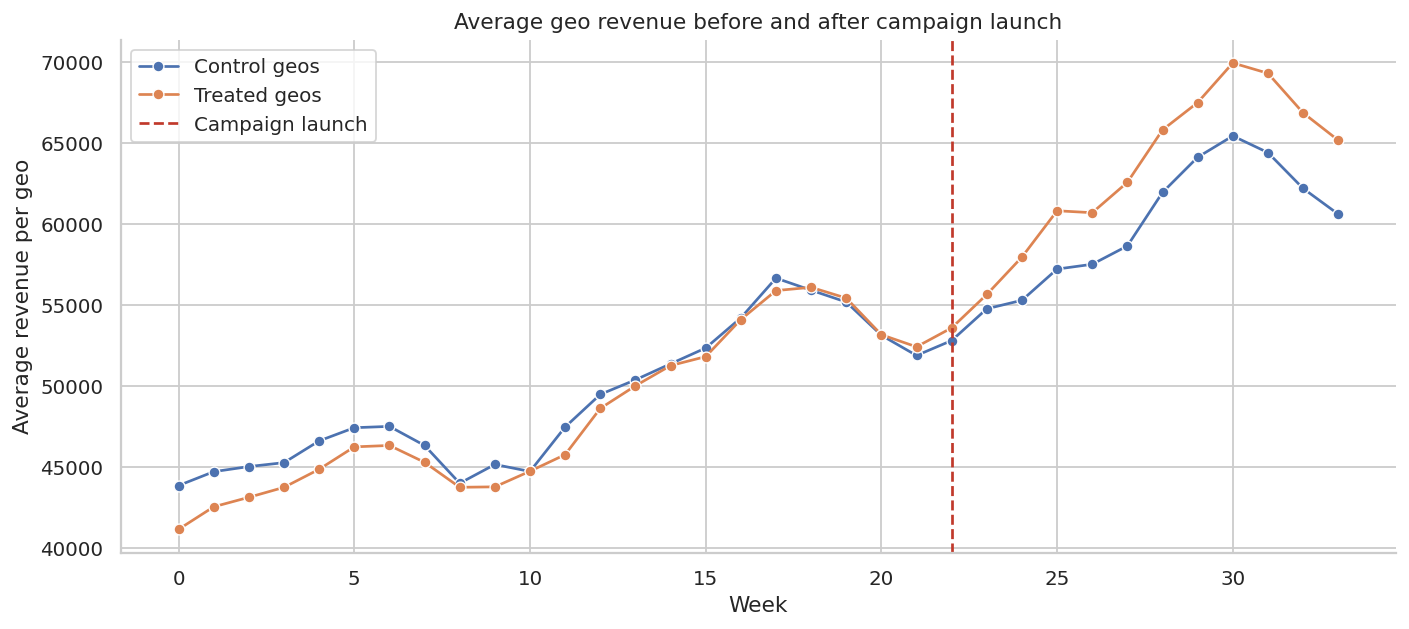

In [12]:
weekly = (
    geo.groupby(["week", "treated_geo"])
    .agg(revenue=("revenue", "mean"), true_effect=("true_effect", "mean"))
    .reset_index()
    .assign(group=lambda d: np.where(d["treated_geo"].eq(1), "Treated geos", "Control geos"))
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=weekly, x="week", y="revenue", hue="group", marker="o", ax=ax)
ax.axvline(22, color="#C0392B", linestyle="--", label="Campaign launch")
ax.set_title("Average geo revenue before and after campaign launch")
ax.set_xlabel("Week")
ax.set_ylabel("Average revenue per geo")
ax.legend()
plt.tight_layout()
plt.show()

The pre-period is the credibility check. A convincing geo experiment should not begin with treated markets already moving differently from control markets. In real work, this plot often determines whether the readout is credible.

In [13]:
did_model = smf.ols(
    "revenue ~ treated_post + C(geo) + C(week)",
    data=geo,
).fit(cov_type="cluster", cov_kwds={"groups": geo["geo"]})

coef = did_model.params["treated_post"]
se = did_model.bse["treated_post"]
ci_low = coef - 1.96 * se
ci_high = coef + 1.96 * se

treated_post_rows = geo["treated_post"].sum()
estimated_incremental_revenue = coef * treated_post_rows
true_incremental_revenue_geo = geo["true_effect"].sum()
geo_spend = geo["spend"].sum()
geo_attributed = geo["attributed_revenue"].sum()

geo_readout = pd.DataFrame(
    {
        "metric": [
            "Estimated lift per treated geo-week",
            "95% CI lower",
            "95% CI upper",
            "Treated post geo-weeks",
            "Estimated incremental revenue",
            "True incremental revenue",
            "Campaign spend",
            "Attributed revenue",
            "Attributed ROAS",
            "Incremental ROAS",
            "True iROAS",
        ],
        "value": [
            coef,
            ci_low,
            ci_high,
            treated_post_rows,
            estimated_incremental_revenue,
            true_incremental_revenue_geo,
            geo_spend,
            geo_attributed,
            geo_attributed / geo_spend,
            estimated_incremental_revenue / geo_spend,
            true_incremental_revenue_geo / geo_spend,
        ],
    }
)

display(geo_readout)

,metric,value
0,Estimated lift per treated geo-week,4.247344e+03
1,95% CI lower,7.827806e+02
2,95% CI upper,7.711907e+03
3,Treated post geo-weeks,2.880000e+02
4,Estimated incremental revenue,1.223235e+06
5,True incremental revenue,6.012050e+05
6,Campaign spend,1.801699e+05
7,Attributed revenue,1.240844e+06
8,Attributed ROAS,6.887076e+00
9,Incremental ROAS,6.789341e+00


The difference-in-differences estimate is interpreted as the average revenue lift per treated geo-week after controlling for:

- stable market differences through geo fixed effects,
- common weekly shocks through week fixed effects,
- the treated-versus-control post-period contrast through the treatment indicator.

The campaign-level incremental revenue multiplies the per-geo-week effect by the number of treated post-period geo-weeks.

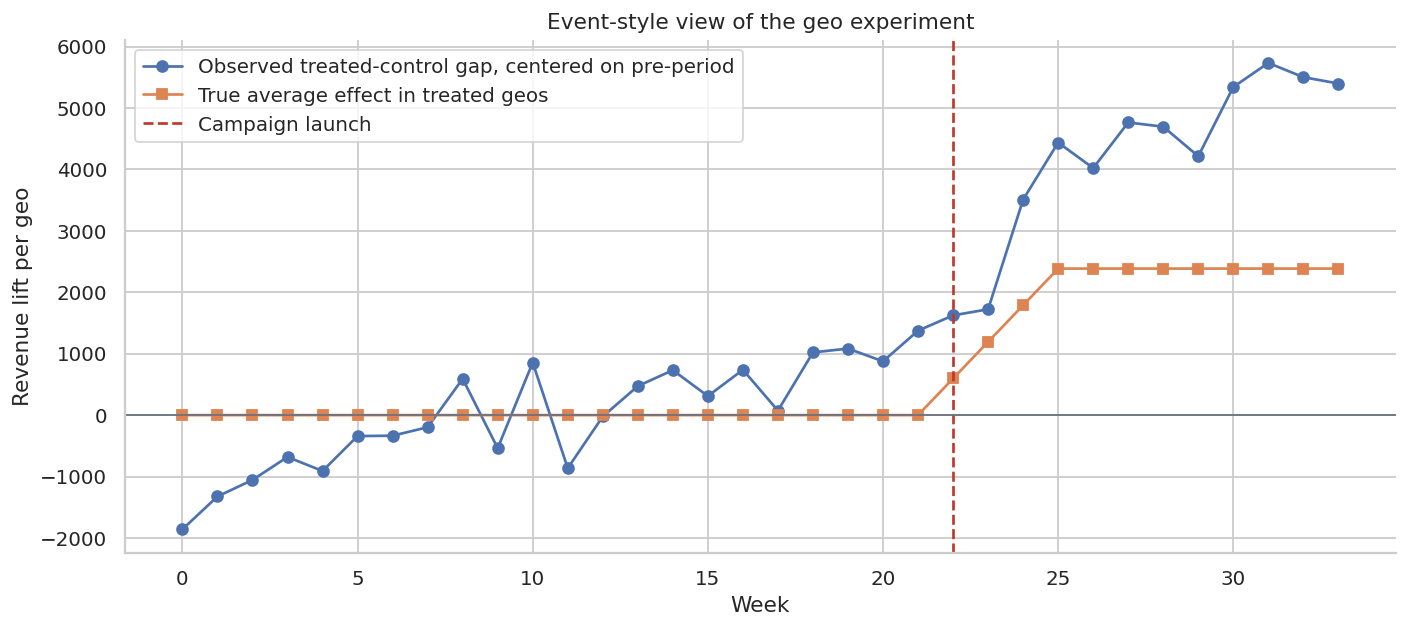

In [14]:
gap = (
    geo.groupby(["week", "treated_geo"])["revenue"]
    .mean()
    .unstack("treated_geo")
    .rename(columns={0: "control", 1: "treated"})
)
gap["treated_minus_control"] = gap["treated"] - gap["control"]
baseline_gap = gap.loc[gap.index < 22, "treated_minus_control"].mean()
gap["did_gap"] = gap["treated_minus_control"] - baseline_gap

true_weekly_effect = (
    geo.query("treated_geo == 1")
    .groupby("week")["true_effect"]
    .mean()
    .rename("true_effect")
)
gap = gap.join(true_weekly_effect)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(gap.index, gap["did_gap"], marker="o", label="Observed treated-control gap, centered on pre-period")
ax.plot(gap.index, gap["true_effect"], marker="s", label="True average effect in treated geos")
ax.axvline(22, color="#C0392B", linestyle="--", label="Campaign launch")
ax.axhline(0, color="#6B7280", linewidth=1)
ax.set_title("Event-style view of the geo experiment")
ax.set_xlabel("Week")
ax.set_ylabel("Revenue lift per geo")
ax.legend()
plt.tight_layout()
plt.show()

This event-style plot is a compact diagnostic:

- Before launch, the centered gap should hover around zero.
- After launch, a credible campaign effect should appear as a sustained deviation.
- If the gap starts changing before launch, the design may be confounded by pre-trends.

In a real readout, this plot often matters as much as the point estimate.

## 6. Matched-Market Synthetic Control

Sometimes only one market or a small number of markets receive treatment. A simple treated-versus-control average may be too crude. In that case, a matched-market or synthetic-control-style approach creates a weighted combination of control markets that resembles the treated market before launch.

The idea is:

$$
\hat{Y}_{1t}(0) = \sum_{j \in \mathcal{D}} w_jY_{jt}
$$

where the donor weights satisfy:

$$
w_j \geq 0,\quad \sum_j w_j = 1
$$

The post-treatment gap is:

$$
Y_{1t} - \hat{Y}_{1t}(0)
$$

We covered synthetic control in the quasi-experiments section. Here we use a lightweight version to show how marketing teams often think about matched markets.

In [15]:
def fit_synthetic_market(df, target_geo, donor_geos, launch_week, outcome="revenue"):
    pre = df.query("week < @launch_week")
    wide_pre = pre.pivot(index="week", columns="geo", values=outcome)
    y = wide_pre[target_geo].to_numpy()
    X = wide_pre[donor_geos].to_numpy()

    def objective(w):
        residual = y - X @ w
        return np.mean(residual**2) + 1e-6 * np.sum(w**2)

    n_donors = len(donor_geos)
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(0, 1)] * n_donors
    start = np.repeat(1 / n_donors, n_donors)

    result = minimize(objective, start, bounds=bounds, constraints=constraints, method="SLSQP")
    weights = pd.Series(result.x, index=donor_geos, name="weight")

    wide_all = df.pivot(index="week", columns="geo", values=outcome)
    synthetic = wide_all[donor_geos] @ weights
    actual = wide_all[target_geo]

    out = pd.DataFrame(
        {
            "week": wide_all.index,
            "actual": actual.values,
            "synthetic_control": synthetic.values,
            "gap": actual.values - synthetic.values,
        }
    )
    return out, weights.sort_values(ascending=False)


treated_markets = geo.groupby("geo")["treated_geo"].first()
target_geo = treated_markets[treated_markets.eq(1)].index[3]
donor_geos = treated_markets[treated_markets.eq(0)].index.tolist()

synth, weights = fit_synthetic_market(geo, target_geo, donor_geos, launch_week=22)
top_weights = weights[weights > 0.02].reset_index().rename(columns={"index": "donor_geo"})

display(top_weights.head(10))

,donor_geo,weight
0,Geo_06,0.041667
1,Geo_08,0.041667
2,Geo_10,0.041667
3,Geo_12,0.041667
4,Geo_13,0.041667
5,Geo_14,0.041667
6,Geo_16,0.041667
7,Geo_17,0.041667
8,Geo_18,0.041667
9,Geo_19,0.041667


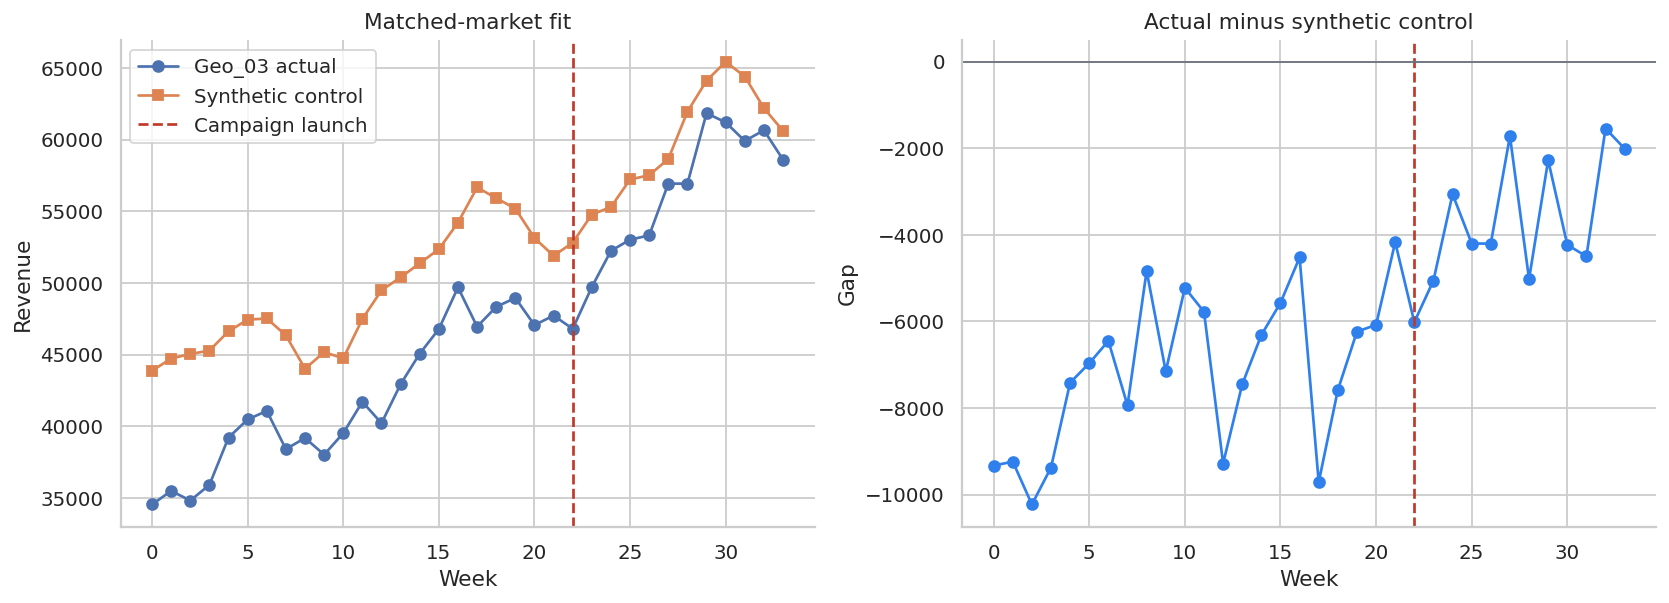

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(synth["week"], synth["actual"], marker="o", label=f"{target_geo} actual")
axes[0].plot(synth["week"], synth["synthetic_control"], marker="s", label="Synthetic control")
axes[0].axvline(22, color="#C0392B", linestyle="--", label="Campaign launch")
axes[0].set_title("Matched-market fit")
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Revenue")
axes[0].legend()

axes[1].plot(synth["week"], synth["gap"], marker="o", color="#2F80ED")
axes[1].axvline(22, color="#C0392B", linestyle="--")
axes[1].axhline(0, color="#6B7280", linewidth=1)
axes[1].set_title("Actual minus synthetic control")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Gap")

plt.tight_layout()
plt.show()

In [17]:
pre_rmse = np.sqrt(np.mean(synth.query("week < 22")["gap"] ** 2))
post_gap = synth.query("week >= 22")["gap"].sum()
target_spend = geo.query("geo == @target_geo and post == 1")["spend"].sum()
target_true = geo.query("geo == @target_geo and post == 1")["true_effect"].sum()

synthetic_readout = pd.DataFrame(
    {
        "metric": [
            "Target market",
            "Pre-period RMSE",
            "Post-period synthetic-control gap",
            "True post-period effect",
            "Spend in target market",
            "Synthetic-control iROAS",
            "True iROAS",
        ],
        "value": [
            target_geo,
            pre_rmse,
            post_gap,
            target_true,
            target_spend,
            post_gap / target_spend,
            target_true / target_spend,
        ],
    }
)

display(synthetic_readout)

,metric,value
0,Target market,Geo_03
1,Pre-period RMSE,7344.595583
2,Post-period synthetic-control gap,-43824.325908
3,True post-period effect,21427.361867
4,Spend in target market,6203.442756
5,Synthetic-control iROAS,-7.064517
6,True iROAS,3.454108


Synthetic-control-style analysis is useful when the pre-period fit is strong and the treated market has a credible donor pool. It is weak when the synthetic control cannot reproduce the treated market before launch.

In marketing, this is why pre-period fit, placebo tests, and market selection matter. A beautiful post-period gap is not persuasive if the pre-period match was poor.

## 7. Attribution ROAS Versus Incremental ROAS

Now let us compare channel-level metrics. This is a common executive question:

> Which channel looks efficient by attribution, and which channel actually creates incremental profit?

The table below is illustrative. It shows how attributed ROAS can rank channels very differently from iROAS. Coviello et al. (2017) studied paid search using a large-scale field experiment and emphasized that measuring marketing spending is difficult; their discussion also shows that substitution between paid and organic traffic can vary across contexts. That is exactly why the causal estimate matters more than the click path alone.

In [18]:
channel_results = pd.DataFrame(
    [
        {
            "channel": "Brand search",
            "spend": 45_000,
            "attributed_revenue": 430_000,
            "incremental_revenue": 70_000,
        },
        {
            "channel": "Paid social prospecting",
            "spend": 82_000,
            "attributed_revenue": 190_000,
            "incremental_revenue": 255_000,
        },
        {
            "channel": "Display retargeting",
            "spend": 32_000,
            "attributed_revenue": 220_000,
            "incremental_revenue": 58_000,
        },
        {
            "channel": "Email promotion",
            "spend": 9_500,
            "attributed_revenue": 68_000,
            "incremental_revenue": 48_000,
        },
        {
            "channel": "Coupon affiliate",
            "spend": 52_000,
            "attributed_revenue": 315_000,
            "incremental_revenue": 42_000,
        },
    ]
)

gross_margin = 0.55
channel_results["attributed_roas"] = channel_results["attributed_revenue"] / channel_results["spend"]
channel_results["iroas"] = channel_results["incremental_revenue"] / channel_results["spend"]
channel_results["contribution_profit"] = gross_margin * channel_results["incremental_revenue"] - channel_results["spend"]
channel_results["decision_signal"] = np.where(channel_results["contribution_profit"] > 0, "Scale or maintain", "Reduce or redesign")

display(
    styled_money_table(
        channel_results,
        money_cols=["spend", "attributed_revenue", "incremental_revenue", "contribution_profit"],
        ratio_cols=["attributed_roas", "iroas"],
    )
)

,channel,spend,attributed_revenue,incremental_revenue,attributed_roas,iroas,contribution_profit,decision_signal
0,Brand search,"$45,000","$430,000","$70,000",9.56x,1.56x,"$-6,500",Reduce or redesign
1,Paid social prospecting,"$82,000","$190,000","$255,000",2.32x,3.11x,"$58,250",Scale or maintain
2,Display retargeting,"$32,000","$220,000","$58,000",6.88x,1.81x,$-100,Reduce or redesign
3,Email promotion,"$9,500","$68,000","$48,000",7.16x,5.05x,"$16,900",Scale or maintain
4,Coupon affiliate,"$52,000","$315,000","$42,000",6.06x,0.81x,"$-28,900",Reduce or redesign


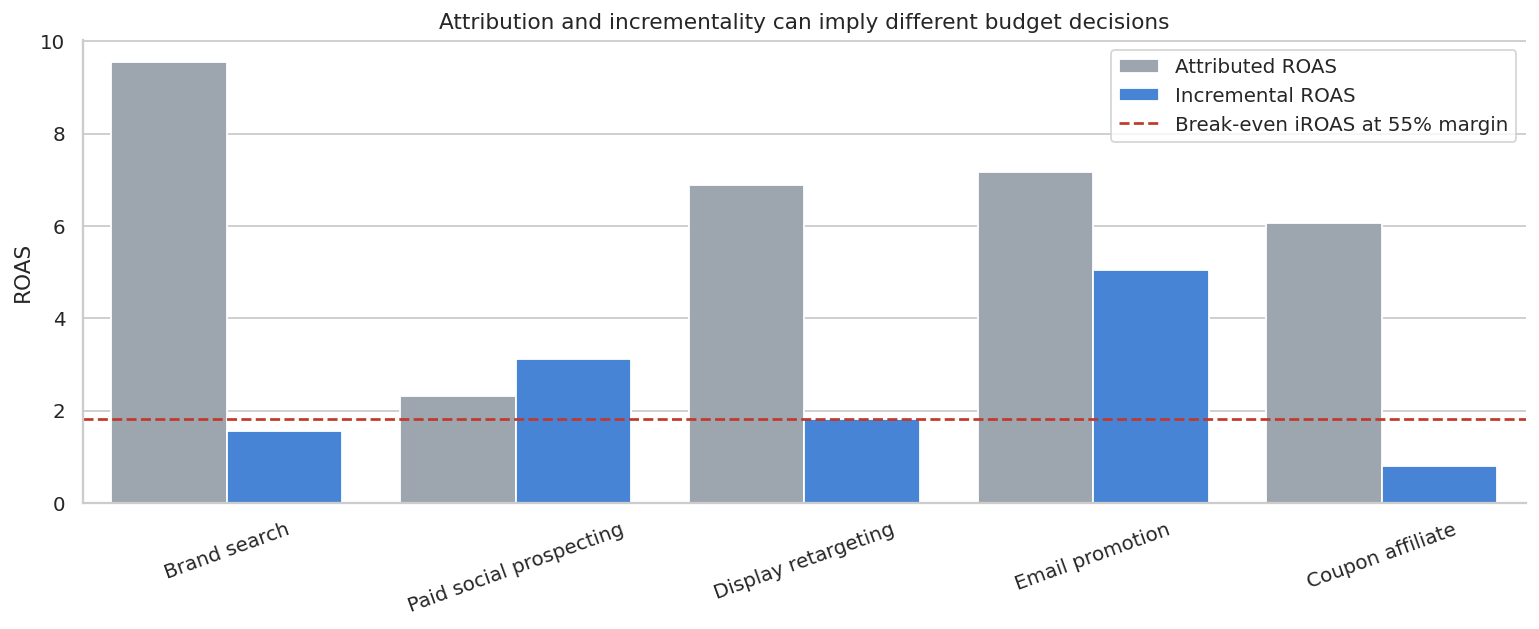

In [19]:
plot_channels = channel_results.melt(
    id_vars="channel",
    value_vars=["attributed_roas", "iroas"],
    var_name="metric",
    value_name="ROAS",
)
plot_channels["metric"] = plot_channels["metric"].map(
    {"attributed_roas": "Attributed ROAS", "iroas": "Incremental ROAS"}
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_channels, x="channel", y="ROAS", hue="metric", ax=ax, palette=["#9AA6B2", "#2F80ED"])
ax.axhline(1 / gross_margin, color="#C0392B", linestyle="--", label="Break-even iROAS at 55% margin")
ax.set_title("Attribution and incrementality can imply different budget decisions")
ax.set_xlabel("")
ax.set_ylabel("ROAS")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

This is the kind of table that changes marketing decisions.

Brand search and coupon affiliates can look outstanding under attribution because they sit close to the purchase decision. But if many of those buyers would have arrived organically, incremental ROAS can be modest. Prospecting can look weaker under last-click attribution while still creating incremental demand.

The right business question is not "Which channel got credit?" It is "Which channel changes the outcome enough to justify its cost?"

## 8. Common Threats in Marketing Incrementality

Marketing experiments have operational failure modes that are easy to miss. The causal design should be paired with a launch checklist.

In [20]:
diagnostics = pd.DataFrame(
    [
        {
            "threat": "Audience contamination",
            "symptom": "Holdout customers still receive treatment through another platform.",
            "diagnostic": "Audit exposure logs by assignment group.",
            "mitigation": "Centralize suppression lists and freeze campaign definitions.",
        },
        {
            "threat": "Auction interference",
            "symptom": "Withholding one group changes bids, prices, or delivery for another group.",
            "diagnostic": "Compare CPM, CPC, frequency, and reach by market and time.",
            "mitigation": "Use geo tests, budget caps, or platform-native ghost ads.",
        },
        {
            "threat": "Budget reallocation",
            "symptom": "Spend removed from holdout geos is automatically pushed into treated geos.",
            "diagnostic": "Check total and per-geo spend paths.",
            "mitigation": "Lock budgets during the test or model spend explicitly.",
        },
        {
            "threat": "Seasonality and events",
            "symptom": "Treatment starts near holidays, launches, press events, or competitor moves.",
            "diagnostic": "Plot pre-period and event windows; inspect calendar shocks.",
            "mitigation": "Use blocked randomization, time fixed effects, or longer pre-periods.",
        },
        {
            "threat": "Weak pre-trends",
            "symptom": "Treated markets were already diverging before launch.",
            "diagnostic": "Pre-period trend plots and placebo launch dates.",
            "mitigation": "Re-match markets, redesign the test, or narrow the claim.",
        },
        {
            "threat": "Short measurement window",
            "symptom": "Revenue shifts in timing rather than total demand.",
            "diagnostic": "Track cumulative lift and delayed outcomes.",
            "mitigation": "Pre-specify conversion windows and include longer-term guardrails.",
        },
        {
            "threat": "Margin and cannibalization",
            "symptom": "Revenue lift comes from discounts, low-margin products, or channel switching.",
            "diagnostic": "Measure contribution margin, product mix, and organic traffic.",
            "mitigation": "Use profit outcomes, not only revenue outcomes.",
        },
    ]
)

display(diagnostics)

,threat,symptom,diagnostic,mitigation
0,Audience contamination,Holdout customers still receive treatment thro...,Audit exposure logs by assignment group.,Centralize suppression lists and freeze campai...
1,Auction interference,"Withholding one group changes bids, prices, or...","Compare CPM, CPC, frequency, and reach by mark...","Use geo tests, budget caps, or platform-native..."
2,Budget reallocation,Spend removed from holdout geos is automatical...,Check total and per-geo spend paths.,Lock budgets during the test or model spend ex...
3,Seasonality and events,"Treatment starts near holidays, launches, pres...",Plot pre-period and event windows; inspect cal...,"Use blocked randomization, time fixed effects,..."
4,Weak pre-trends,Treated markets were already diverging before ...,Pre-period trend plots and placebo launch dates.,"Re-match markets, redesign the test, or narrow..."
5,Short measurement window,Revenue shifts in timing rather than total dem...,Track cumulative lift and delayed outcomes.,Pre-specify conversion windows and include lon...
6,Margin and cannibalization,"Revenue lift comes from discounts, low-margin ...","Measure contribution margin, product mix, and ...","Use profit outcomes, not only revenue outcomes."


## 9. Power Planning and Minimum Detectable Effect

Marketing teams often ask whether a test is "big enough." A simple two-sample approximation helps with early planning.

For equal-variance outcomes, a minimum detectable effect is:

$$
\text{MDE} = (z_{1-\alpha/2}+z_{\text{power}})\sqrt{\frac{\sigma^2}{n_t}+\frac{\sigma^2}{n_c}}
$$

This is only an approximation, but it creates a disciplined conversation about traffic, holdout size, outcome variance, and decision thresholds.

In [21]:
def mde_two_sample(sd, n_treat, n_control, alpha=0.05, power=0.80):
    z_alpha = norm.ppf(1 - alpha / 2)
    z_power = norm.ppf(power)
    return (z_alpha + z_power) * sd * np.sqrt(1 / n_treat + 1 / n_control)


revenue_sd = customers["revenue"].std(ddof=1)
planning_rows = []
for audience_size in [25_000, 50_000, 100_000, 250_000]:
    for control_share in [0.05, 0.10, 0.20]:
        n_control = int(audience_size * control_share)
        n_treat = audience_size - n_control
        mde = mde_two_sample(revenue_sd, n_treat, n_control)
        planning_rows.append(
            {
                "audience_size": audience_size,
                "control_share": control_share,
                "n_treat": n_treat,
                "n_control": n_control,
                "mde_revenue_per_customer": mde,
                "mde_total_revenue_on_treated": mde * n_treat,
            }
        )

power_plan = pd.DataFrame(planning_rows)

display(
    styled_money_table(
        power_plan,
        money_cols=["mde_revenue_per_customer", "mde_total_revenue_on_treated"],
        pct_cols=["control_share"],
    )
)

,audience_size,control_share,n_treat,n_control,mde_revenue_per_customer,mde_total_revenue_on_treated
0,25000,5.00%,23750,1250,$2,"$36,638"
1,25000,10.00%,22500,2500,$1,"$25,216"
2,25000,20.00%,20000,5000,$1,"$16,810"
3,50000,5.00%,47500,2500,$1,"$51,813"
4,50000,10.00%,45000,5000,$1,"$35,660"
5,50000,20.00%,40000,10000,$1,"$23,774"
6,100000,5.00%,95000,5000,$1,"$73,275"
7,100000,10.00%,90000,10000,$1,"$50,431"
8,100000,20.00%,80000,20000,$0,"$33,621"
9,250000,5.00%,237500,12500,$0,"$115,858"


Power planning is where the statistician can be especially valuable in industry.

If the MDE is much larger than the effect size that would change the budget decision, the test is underpowered for the decision. That does not mean the test is useless, but it means the readout should be framed as directional learning rather than definitive proof.

## 10. Decision Memo Template

A professional incrementality readout should not stop at a coefficient. It should connect design, estimate, uncertainty, spend, and recommendation.

In [22]:
margin = 0.55
geo_profit = margin * estimated_incremental_revenue - geo_spend
geo_ci_profit_low = margin * (ci_low * treated_post_rows) - geo_spend
geo_ci_profit_high = margin * (ci_high * treated_post_rows) - geo_spend

memo = f'''
### Marketing Incrementality Readout

**Decision:** Whether to maintain, scale, or redesign the paid media campaign.

**Design:** Geo-level incrementality test with treated and control markets observed before and after launch.

**Primary estimand:** Average incremental revenue per treated geo-week after campaign launch.

**Estimate:** {dollars(coef, 0)} incremental revenue per treated geo-week.

**95% confidence interval:** {dollars(ci_low, 0)} to {dollars(ci_high, 0)} per treated geo-week.

**Campaign-level incremental revenue:** {dollars(estimated_incremental_revenue, 0)}.

**Campaign spend:** {dollars(geo_spend, 0)}.

**Incremental ROAS:** {ratio(estimated_incremental_revenue / geo_spend, 2)}.

**Contribution profit at {pct(margin, 0)} gross margin:** {dollars(geo_profit, 0)}.

**Profit uncertainty range:** {dollars(geo_ci_profit_low, 0)} to {dollars(geo_ci_profit_high, 0)}.

**Recommendation:** Maintain the campaign if the business is comfortable with the uncertainty range; scale only after confirming pre-trend diagnostics, spend stability, and no major channel cannibalization.
'''

display(Markdown(memo))


### Marketing Incrementality Readout

**Decision:** Whether to maintain, scale, or redesign the paid media campaign.

**Design:** Geo-level incrementality test with treated and control markets observed before and after launch.

**Primary estimand:** Average incremental revenue per treated geo-week after campaign launch.

**Estimate:** $4,247 incremental revenue per treated geo-week.

**95% confidence interval:** $783 to $7,712 per treated geo-week.

**Campaign-level incremental revenue:** $1,223,235.

**Campaign spend:** $180,170.

**Incremental ROAS:** 6.79x.

**Contribution profit at 55% gross margin:** $492,609.

**Profit uncertainty range:** $-56,177 to $1,041,396.

**Recommendation:** Maintain the campaign if the business is comfortable with the uncertainty range; scale only after confirming pre-trend diagnostics, spend stability, and no major channel cannibalization.


Notice the tone of the recommendation. A causal readout should not pretend uncertainty does not exist. It should explain what decision is supported and what risks remain.

## 11. Practical Workflow

A strong industry incrementality project usually follows this sequence:

1. Define the decision before defining the model.
2. Choose the unit of assignment: customer, household, store, geo, or time block.
3. Define the treatment, suppression rules, and measurement window.
4. Pre-specify the primary outcome and guardrail outcomes.
5. Estimate power and agree on the minimum decision-relevant effect.
6. Launch with tracking checks in the first day or week.
7. Read out balance, exposure, spend, pre-trends, point estimates, uncertainty, iROAS, and profit.
8. Convert the result into a budget action.
9. Store the result in an experiment registry for future meta-analysis.

This is what makes the work look professional: not just the estimator, but the full measurement operating system around it.

## 12. Hands-On Extensions

Try extending this notebook in the following ways:

- Replace revenue with contribution margin and compare decisions.
- Add delayed conversions and estimate cumulative lift over multiple windows.
- Add spillovers between neighboring geos.
- Run placebo launch dates in the pre-period.
- Compare a simple DiD estimate with a synthetic control estimate for all treated geos.
- Use customer covariates to post-stratify the holdout experiment.
- Build an uplift model using the randomized customer-level experiment.

## Key Takeaways

- Attribution assigns credit; incrementality estimates causal lift.
- A holdout group is the cleanest way to estimate marketing lift when customer-level randomization is feasible.
- Rare purchases and small control groups can make advertising lift estimates noisy.
- Geo tests are useful when user-level randomization is infeasible, but they require careful pre-trend and spend diagnostics.
- Synthetic-control-style matched markets are persuasive only when the pre-period fit is credible.
- iROAS and contribution profit are closer to budget decisions than attributed ROAS.
- A professional readout connects the causal estimate to the decision, uncertainty, and operational caveats.

## References

Barajas, J., Bhamidipati, N., & Shanahan, J. G. (2021). Online advertising incrementality testing and experimentation. *Proceedings of the 27th ACM SIGKDD Conference on Knowledge Discovery & Data Mining*, 4027-4028. https://doi.org/10.1145/3447548.3470819

Berman, R., & Feit, E. M. (2019). Latent stratification for incrementality experiments. *arXiv*. https://doi.org/10.48550/arxiv.1911.08438

Coviello, L., Gneezy, U., & Goette, L. (2017). A large-scale field experiment to evaluate the effectiveness of paid search advertising. *SSRN Electronic Journal*. https://doi.org/10.2139/ssrn.3061698

Lambrecht, A., & Tucker, C. E. (2013). When does retargeting work? Information specificity in online advertising. *Journal of Marketing Research, 50*(5), 561-576. https://doi.org/10.1509/jmr.11.0503

Lewis, R. A., & Wong, J. (2018). Incrementality bidding & attribution. *SSRN Electronic Journal*. https://doi.org/10.2139/ssrn.3129350